In [ ]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
import h5py
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [ ]:
beta = 10.0

DATA_DIR = Path.cwd().parent.parent / "data" / "darcy_flow_data" 
scale_factor = 1
FILE_PATH = DATA_DIR / f"2D_DarcyFlow_beta10.0_Train_Scale{scale_factor}.hdf5"

In [ ]:
epochs = 100
M = 1024
chunk_size = 256
hidden_layers = [512, 512, 512, 512]

total_features = hidden_layers[-1]

# Kaczmarz Settings (from Poisson Gauss)
kaczmarz_sweeps = 20
kaczmarz_alpha = 0.3
kaczmarz_tik_reg = 1e-5 # Brought over from Darcy

# Loss weights (from Darcy)
matrix_bc_weight = 1e4
pde_loss_weight = 1.0
bc_loss_weight = 1e4
data_loss_weight = 0

print(f"Total Features configured: {total_features}")

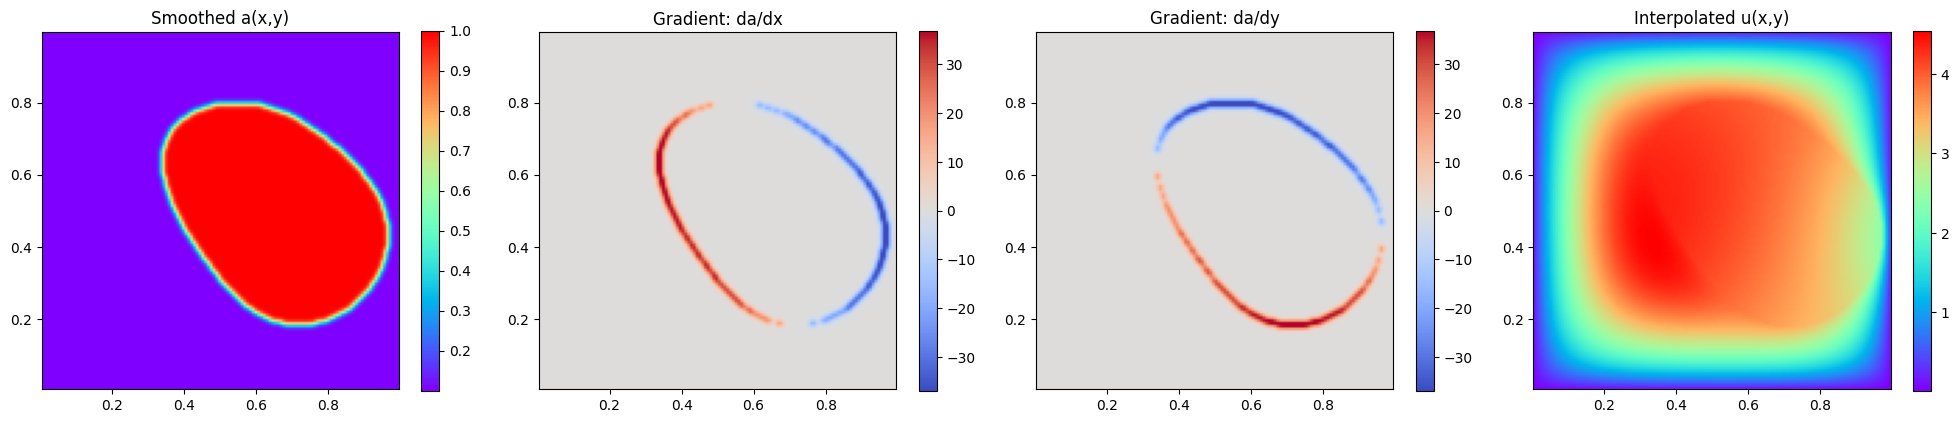

In [4]:
sample_idx = 0

with h5py.File(FILE_PATH, 'r') as f:
    # 1. Get grid dimensions
    fine_x = f['x-coordinate'][:]
    fine_y = f['y-coordinate'][:]
    fine_nx, fine_ny = len(fine_x), len(fine_y)
    
    # 2. Extract the sample and reshape back to 2D
    a_2d = f['a_flat'][sample_idx].reshape(fine_nx, fine_ny)
    ax_2d = f['a_x_flat'][sample_idx].reshape(fine_nx, fine_ny)
    ay_2d = f['a_y_flat'][sample_idx].reshape(fine_nx, fine_ny)
    u_2d = f['u_flat'][sample_idx].reshape(fine_nx, fine_ny)

# --- Numerical Checks ---
print(f"--- Numerical Sanity Checks (Sample {sample_idx}) ---")
print(f"Contains NaNs: {np.isnan(a_2d).any() or np.isnan(u_2d).any()}")

u_boundaries = np.concatenate([
    u_2d[0, :], u_2d[-1, :],
    u_2d[:, 0], u_2d[:, -1] 
])
max_boundary_val = np.max(np.abs(u_boundaries))
print(f"Max absolute value on u boundaries: {max_boundary_val:.6e} (Should be ~0.0)")

# --- Visual Checks ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
ext = [fine_x.min(), fine_x.max(), fine_y.min(), fine_y.max()]

im0 = axes[0].imshow(a_2d.T, origin='lower', cmap='rainbow', extent=ext)
axes[0].set_title("Smoothed a(x,y)")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ax_2d.T, origin='lower', cmap='coolwarm', extent=ext)
axes[1].set_title("Gradient: da/dx")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(ay_2d.T, origin='lower', cmap='coolwarm', extent=ext)
axes[2].set_title("Gradient: da/dy")
fig.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(u_2d.T, origin='lower', cmap='rainbow', extent=ext)
axes[3].set_title("Interpolated u(x,y)")
fig.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

In [5]:
class DarcyFlowDataset(Dataset):
    def __init__(self, a_data, a_x_data, a_y_data, u_data):
        self.a = a_data
        self.a_x = a_x_data
        self.a_y = a_y_data
        self.u = u_data

    def __len__(self): return len(self.a)
    def __getitem__(self, idx): return self.a[idx], self.a_x[idx], self.a_y[idx], self.u[idx]

print(f"Loading pre-processed dataset: {FILE_PATH.name}")

with h5py.File(FILE_PATH, 'r') as f:
    fine_x_coords = np.array(f['x-coordinate'][:])
    fine_y_coords = np.array(f['y-coordinate'][:])
    
    all_a_flat = np.array(f['a_flat'][:])
    all_a_x_flat = np.array(f['a_x_flat'][:])
    all_a_y_flat = np.array(f['a_y_flat'][:])
    all_u_flat = np.array(f['u_flat'][:])

N_samples = all_a_flat.shape[0]
fine_nx, fine_ny = len(fine_x_coords), len(fine_y_coords)

# Coordinate generation
x_l, x_u = float(np.min(fine_x_coords)), float(np.max(fine_x_coords)) 
y_l, y_u = float(np.min(fine_y_coords)), float(np.max(fine_y_coords)) 

X, Y = np.meshgrid(fine_x_coords, fine_y_coords, indexing='ij')
x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_valid = x
y_valid = y

edge_x = jnp.linspace(0.0, 1.0, fine_nx)
edge_y = jnp.linspace(0.0, 1.0, fine_ny)

bc_bottom = jnp.stack([edge_x, jnp.zeros_like(edge_x)], axis=-1)
bc_top = jnp.stack([edge_x, jnp.ones_like(edge_x)], axis=-1)
bc_left = jnp.stack([jnp.zeros_like(edge_y), edge_y], axis=-1)
bc_right = jnp.stack([jnp.ones_like(edge_y), edge_y], axis=-1)

all_bc_coords = jnp.concatenate([bc_bottom, bc_top, bc_left, bc_right], axis=0)
x_bc = all_bc_coords[:, 0].reshape(-1, 1)
y_bc = all_bc_coords[:, 1].reshape(-1, 1)

bc_val_array = jnp.zeros_like(x_bc)

# Dataloaders
n_train = 10
n_val = 5
n_test = 5
N_subset = n_train + n_val + n_test

train_dataset = DarcyFlowDataset(
    all_a_flat[:n_train], all_a_x_flat[:n_train], all_a_y_flat[:n_train], all_u_flat[:n_train]
)
val_dataset = DarcyFlowDataset(
    all_a_flat[n_train : n_train + n_val], all_a_x_flat[n_train : n_train + n_val], 
    all_a_y_flat[n_train : n_train + n_val], all_u_flat[n_train : n_train + n_val]
)
test_dataset = DarcyFlowDataset(
    all_a_flat[n_train + n_val : N_subset], all_a_x_flat[n_train + n_val : N_subset], 
    all_a_y_flat[n_train + n_val : N_subset], all_u_flat[n_train + n_val : N_subset]
)

batch_size_samples = 10 
train_dataloader = jd.DataLoader(train_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=True, drop_last=True)
val_dataloader = jd.DataLoader(val_dataset, backend='pytorch', batch_size=n_val, shuffle=False)
test_dataloader = jd.DataLoader(test_dataset, backend='pytorch', batch_size=n_test, shuffle=False)

print(f"DataLoaders ready! (Train: {n_train}, Val: {n_val}, Test: {n_test})")

Loading pre-processed dataset: 2D_DarcyFlow_beta10.0_Train_Scale1.hdf5


E0723 21:01:22.926964   37727 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0723 21:01:22.938797   37545 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


DataLoaders ready! (Train: 10, Val: 5, Test: 5)


In [6]:
sigma = 1.0 
rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2, M)) * sigma

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        self.param('raw_lambda', nn.initializers.constant(-3.0), (1,))
        
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
        return h 

model = FeatureExtractor(
    hidden_layers=hidden_layers, 
    B_matrix=B_matrix 
)

key = jax.random.PRNGKey(0)
dummy_x = jnp.array([0.0])
dummy_y = jnp.array([0.0])
params = model.init(key, dummy_x, dummy_y)

In [7]:
def get_u_simple(params, x_val, y_val, w_single):
    f_val = model.apply(params, x_val, y_val)
    return jnp.dot(f_val, w_single)[0]

def get_u_dir_simple(params, x_val, y_val, w_single):
    def u_fn(x, y): return get_u_simple(params, x, y, w_single)
    
    u_x = jacfwd(u_fn, argnums=0)(x_val, y_val)
    u_y = jacfwd(u_fn, argnums=1)(x_val, y_val)
    u_xx = jacfwd(jacfwd(u_fn, argnums=0), argnums=0)(x_val, y_val)
    u_yy = jacfwd(jacfwd(u_fn, argnums=1), argnums=1)(x_val, y_val)
    
    return u_x, u_y, u_xx, u_yy

u_dir_spatial_vmap = jax.vmap(get_u_dir_simple, in_axes=(None, 0, 0, None))
u_spatial_vmap = jax.vmap(get_u_simple, in_axes=(None, 0, 0, None))

In [8]:
def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_x = jacfwd(get_f, argnums=1)(params, x_val, y_val)
    f_y = jacfwd(get_f, argnums=2)(params, x_val, y_val)
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_x = jnp.squeeze(f_x, axis=-1)
    f_y = jnp.squeeze(f_y, axis=-1)
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    return f_x, f_y, f_xx, f_yy

f_spatial_vmap = jax.vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = jax.vmap(get_f_dir, in_axes=(None, 0, 0))

In [9]:
def universal_chunked_loss(eval_residual_fn, x_full, y_full, target_full, chunk_size_internal):
    total_points = x_full.shape[0]
    num_chunks = total_points // chunk_size_internal

    x_reshaped = x_full.reshape((num_chunks, chunk_size_internal, 1))
    y_reshaped = y_full.reshape((num_chunks, chunk_size_internal, 1))
    
    if target_full is not None:
        t_reshaped = target_full.reshape((num_chunks, chunk_size_internal, target_full.shape[-1]))
    else:
        t_reshaped = jnp.zeros_like(x_reshaped)

    @jax.checkpoint
    def scan_step(loss_sum, chunk_data):
        x_chunk, y_chunk, t_chunk = chunk_data
        t_val = None if target_full is None else t_chunk
        
        residual = eval_residual_fn(x_chunk, y_chunk, t_val)
        chunk_loss_sum = jnp.sum(residual ** 2)
        
        return loss_sum + chunk_loss_sum, None

    total_loss_sum, _ = jax.lax.scan(scan_step, 0.0, (x_reshaped, y_reshaped, t_reshaped))
    return total_loss_sum / total_points

def compute_loss_single_modular(params, w_single, x_pde, y_pde, a_pde, a_x_pde, a_y_pde, x_bc, y_bc, bc_val_arr, pde_chunk_size, bc_chunk_size):
    
    stacked_a_targets = jnp.concatenate([a_pde, a_x_pde, a_y_pde], axis=-1)
    
    def pde_residual_fn(x_c, y_c, t_c):
        a_c = t_c[..., 0:1]
        a_x_c = t_c[..., 1:2]
        a_y_c = t_c[..., 2:3]
        
        u_x, u_y, u_xx, u_yy = u_dir_spatial_vmap(params, x_c, y_c, w_single)
        
        u_x = u_x.reshape(-1, 1)
        u_y = u_y.reshape(-1, 1)
        laplacian_u = u_xx.reshape(-1, 1) + u_yy.reshape(-1, 1)
        
        residual = -(a_x_c * u_x + a_y_c * u_y + a_c * laplacian_u) - beta
        return residual * jnp.sqrt(pde_loss_weight)
        
    loss_pde = universal_chunked_loss(pde_residual_fn, x_pde, y_pde, stacked_a_targets, pde_chunk_size)
    
    def bc_residual_fn(x_c, y_c, u_bc_c):
        u_bc_pred = u_spatial_vmap(params, x_c, y_c, w_single)
        u_bc_pred = u_bc_pred.reshape(-1, 1) 
        return (u_bc_pred - u_bc_c) * jnp.sqrt(bc_loss_weight) 
        
    loss_bc = universal_chunked_loss(bc_residual_fn, x_bc, y_bc, bc_val_arr, bc_chunk_size)

    return loss_pde + loss_bc

batched_compute_loss_modular = jax.vmap(
    compute_loss_single_modular, 
    in_axes=(None, 0, None, None, 0, 0, 0, None, None, None, None, None) 
)

In [10]:
def kaczmarz_inner_update(params, w_k, x_pde, y_pde, a_pde, a_x_pde, a_y_pde, x_bc, y_bc, bc_val_arr, alpha, tik_reg):
    b_pde = jnp.ones_like(a_pde) * beta
    b_bc = bc_val_arr * jnp.sqrt(matrix_bc_weight)
    b_block = jnp.vstack([b_pde, b_bc])
    
    N_rows = b_block.shape[0]
    
    # 1. Compute PDE Matrix (Single-Shot)
    f_x, f_y, f_xx, f_yy = f_dir_spatial_vmap(params, x_pde, y_pde)
    A_pde = -(a_x_pde * f_x + a_y_pde * f_y + a_pde * (f_xx + f_yy))
    
    # 2. Compute BC Matrix (Single-Shot)
    A_bc = f_spatial_vmap(params, x_bc, y_bc) * jnp.sqrt(matrix_bc_weight)
    
    # 3. Assemble and Solve (No chunking required for 256 features!)
    A = jnp.vstack([A_pde, A_bc])
    Aw = A @ w_k
    G = A @ A.T
    
    I = jnp.eye(N_rows)
    z = jnp.linalg.solve(G + tik_reg * I, Aw - b_block)
    
    # 4. Project Weights
    w_new = w_k - alpha * (A.T @ z)
    return w_new

@jax.jit(static_argnames=['total_features', 'spatial_chunk_size', 'num_sweeps'])
def solve_single_sample(params, x_pde_full, y_pde_full, a_full, a_x_full, a_y_full, x_bc, y_bc, bc_val_arr, total_features, spatial_chunk_size, alpha, tik_reg, num_sweeps):
    w_init = jnp.zeros((total_features, 1))
    
    total_spatial_points = x_pde_full.shape[0]
    num_spatial_chunks = total_spatial_points // spatial_chunk_size
    
    x_reshaped = x_pde_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))
    y_reshaped = y_pde_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))
    a_reshaped = a_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))
    a_x_reshaped = a_x_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))
    a_y_reshaped = a_y_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))

    def sweep_step(w_carry_sweep, _):
        @jax.checkpoint
        def spatial_step(w_carry_spatial, chunk_data):
            x_pde_chunk, y_pde_chunk, a_chunk, a_x_chunk, a_y_chunk = chunk_data
            
            w_next = kaczmarz_inner_update(
                params, w_carry_spatial, x_pde_chunk, y_pde_chunk, a_chunk, a_x_chunk, a_y_chunk, 
                x_bc, y_bc, bc_val_arr, 
                alpha, tik_reg
            )
            return w_next, None

        w_sweep_final, _ = jax.lax.scan(
            spatial_step, 
            w_carry_sweep, 
            (x_reshaped, y_reshaped, a_reshaped, a_x_reshaped, a_y_reshaped)
        )
        return w_sweep_final, None

    w_final, _ = jax.lax.scan(sweep_step, w_init, jnp.arange(num_sweeps))
    return w_final

batched_solve = jax.vmap(
    solve_single_sample, 
    in_axes=(None, None, None, 0, 0, 0, None, None, None, None, None, None, None, None) 
)

@jax.jit(static_argnames=['total_features', 'spatial_chunk_size', 'num_sweeps'])
def update_kaczmarz_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, spatial_chunk_size, alpha, tik_reg, num_sweeps):
    
    w_batch = batched_solve(
        params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, 
        x_bc, y_bc, bc_val_arr, 
        total_features, spatial_chunk_size, alpha, tik_reg, num_sweeps
    )
    return w_batch

In [11]:
total_steps = epochs * len(train_dataloader)
lr_schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=total_steps, alpha=0.01)
optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)

def full_forward_and_loss(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, spatial_chunk_size, bc_chunk_size):
    raw_val = params['params']['raw_lambda'][0]
    tik_reg = 10 ** (jnp.tanh(raw_val) * 3 - 2) 
    
    w_batch = update_kaczmarz_batch(
        params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, 
        total_features, spatial_chunk_size, kaczmarz_alpha, tik_reg, kaczmarz_sweeps
    )
    w_batch = jax.lax.stop_gradient(w_batch)
    
    batched_loss = batched_compute_loss_modular(
        params, w_batch, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, 
        x_bc, y_bc, bc_val_arr, 
        spatial_chunk_size, bc_chunk_size
    )
    return jnp.mean(batched_loss), tik_reg

loss_grad_fn = jax.jit(
    value_and_grad(full_forward_and_loss, argnums=0, has_aux=True), 
    static_argnames=['total_features', 'spatial_chunk_size', 'bc_chunk_size']
)

@jax.jit(static_argnames=['total_features', 'spatial_chunk_size', 'bc_chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, spatial_chunk_size, bc_chunk_size):
    
    (loss, current_lambda), grads = loss_grad_fn(
        params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, 
        total_features, spatial_chunk_size, bc_chunk_size
    )
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss, current_lambda

In [12]:
def predict_u_single(params, x_val, y_val, w_single):    
    u_pred_total = u_spatial_vmap(params, x_val, y_val, w_single)
    return u_pred_total.reshape(-1, 1)

batched_predict_u = jax.vmap(
    predict_u_single, 
    in_axes=(None, None, None, 0)
)

@jax.jit
def fast_eval_step(params, w_batch, x_grid, y_grid, u_batch):    
    u_pred_batch = batched_predict_u(params, x_grid, y_grid, w_batch)
    return jnp.mean((u_pred_batch - u_batch)**2)

def evaluate_dataset(dataloader, params, x_grid, y_grid, eval_batch_size, eval_chunk_size):
    total_mse = 0.0
    total_samples = 0
    
    rng = jax.random.PRNGKey(0)
    total_points = x_grid.shape[0]
    
    val_spatial_idx = jax.random.choice(rng, jnp.arange(total_points), shape=(eval_batch_size,), replace=False)
    
    test_x_chunk = x_grid[val_spatial_idx]
    test_y_chunk = y_grid[val_spatial_idx]
    
    for a_batch, a_x_batch, a_y_batch, u_batch in dataloader:
        a_chunk_val = a_batch[:, val_spatial_idx].reshape(-1, eval_batch_size, 1)
        a_x_chunk_val = a_x_batch[:, val_spatial_idx].reshape(-1, eval_batch_size, 1)
        a_y_chunk_val = a_y_batch[:, val_spatial_idx].reshape(-1, eval_batch_size, 1)
        u_chunk_val = u_batch[:, val_spatial_idx].reshape(-1, eval_batch_size, 1) 
        
        raw_val = params['params']['raw_lambda'][0]
        learned_lambda = 10 ** (jnp.tanh(raw_val) * 3 - 2)
        
        w_val_batch = update_kaczmarz_batch(
            params, test_x_chunk, test_y_chunk, a_chunk_val, a_x_chunk_val, a_y_chunk_val, 
            x_bc, y_bc, bc_val_array, 
            total_features, eval_chunk_size, kaczmarz_alpha, learned_lambda, kaczmarz_sweeps
        )
       
        batch_mse = fast_eval_step(params, w_val_batch, test_x_chunk, test_y_chunk, u_chunk_val)
        
        current_batch_size = a_batch.shape[0]
        total_mse += batch_mse.item() * current_batch_size
        total_samples += current_batch_size
            
    return total_mse / total_samples

In [13]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

# Interior Sampling
total_points = x.shape[0] 
spatial_batch_size = 10000
spatial_chunk_size = 250   

# Boundary Sampling
total_bc_points = x_bc.shape[0]
bc_batch_size = 500
bc_chunk_size = 250

rng, pde_key, bc_key = jax.random.split(rng, 3)
spatial_indices = jax.random.permutation(pde_key, total_points)
bc_indices = jax.random.permutation(bc_key, total_bc_points)

ptr, bc_ptr = 0, 0 
history_total = []

for epoch in range(epochs):
    epoch_loss = 0.0
    num_batches = 0
    
    for a_batch, a_x_batch, a_y_batch, u_batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        
        if ptr + spatial_batch_size > total_points:
            rng, shuffle_key = jax.random.split(rng)
            spatial_indices = jax.random.permutation(shuffle_key, total_points)
            ptr = 0
            
        batch_idx = spatial_indices[ptr : ptr + spatial_batch_size]
        ptr += spatial_batch_size
        
        x_chunk, y_chunk = x[batch_idx], y[batch_idx]
        
        a_chunk = a_batch[:, batch_idx].reshape(a_batch.shape[0], spatial_batch_size, 1)
        a_x_chunk = a_x_batch[:, batch_idx].reshape(a_x_batch.shape[0], spatial_batch_size, 1)
        a_y_chunk = a_y_batch[:, batch_idx].reshape(a_y_batch.shape[0], spatial_batch_size, 1)
        
        if bc_ptr + bc_batch_size > total_bc_points:
            rng, bc_shuffle_key = jax.random.split(rng)
            bc_indices = jax.random.permutation(bc_shuffle_key, total_bc_points)
            bc_ptr = 0
            
        bc_batch_idx = bc_indices[bc_ptr : bc_ptr + bc_batch_size]
        bc_ptr += bc_batch_size
        
        x_bc_chunk, y_bc_chunk = x_bc[bc_batch_idx], y_bc[bc_batch_idx]
        bc_val_chunk = bc_val_array[bc_batch_idx]
        
        params, opt_state, loss, current_lambda = update_network(
            params, opt_state, x_chunk, y_chunk, 
            a_chunk, a_x_chunk, a_y_chunk, 
            x_bc_chunk, y_bc_chunk, bc_val_chunk, 
            total_features, spatial_chunk_size, bc_chunk_size
        )
        
        epoch_loss += loss
        num_batches += 1
        
    avg_train_loss = epoch_loss / num_batches
    history_total.append(avg_train_loss)
    
    val_mse = evaluate_dataset(val_dataloader, params, x, y, spatial_batch_size, spatial_chunk_size)
    
    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4e} | Val MSE: {val_mse:.4e} | TikReg: {current_lambda:.2e}")

Epoch 1/300:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 2.8146e+03 | Val MSE: 1.7878e+00 | TikReg: 1.03e-05


Epoch 2/300:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 3/300:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 4/300:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch 297/300:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 298/300:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 299/300:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 300/300:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 300 | Train Loss: 7.7971e+01 | Val MSE: 2.6865e+00 | TikReg: 1.03e-05


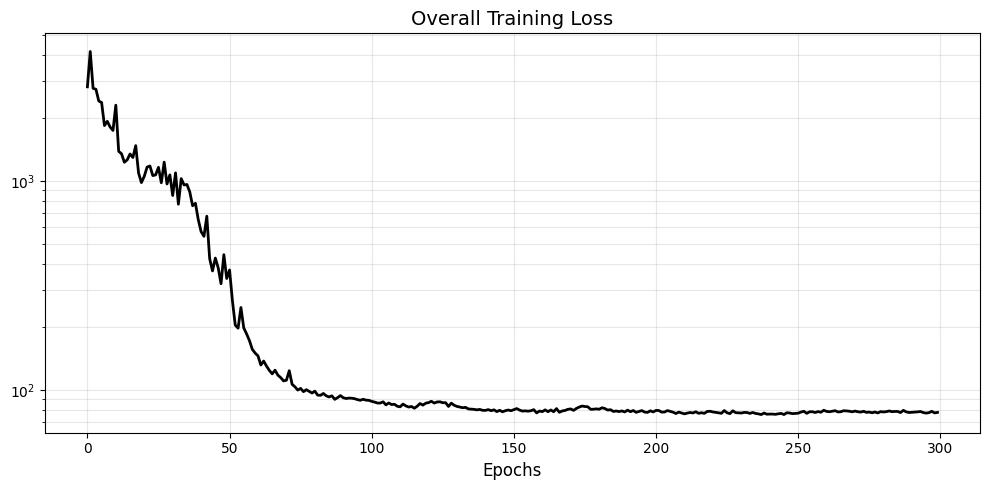

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history_total, color='black', linewidth=2)
ax.set_title('Overall Training Loss', fontsize=14)
ax.set_yscale('log')
ax.set_xlabel('Epochs', fontsize=12)
ax.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

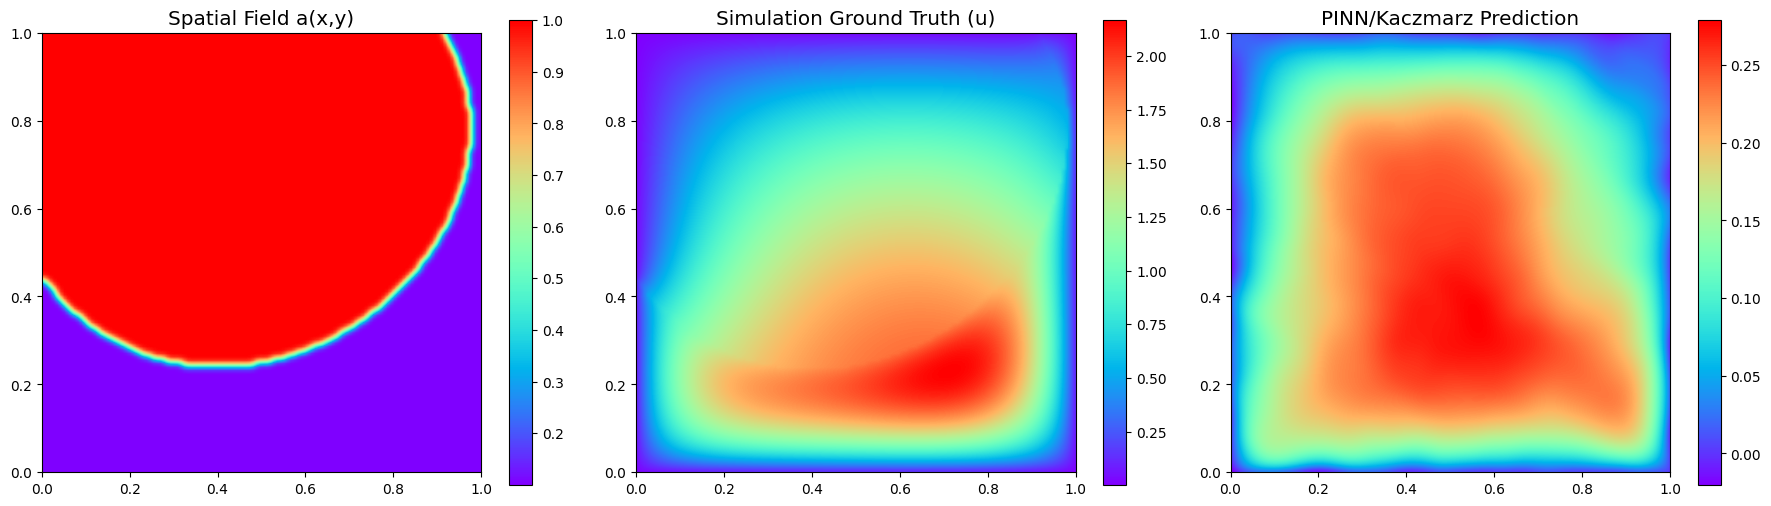

Relative L2 Error: 8.5024e-01 (or 85.02%)


In [17]:
test_idx = 2
a_sample, a_x_sample, a_y_sample, u_sim_sample = test_dataset[test_idx]

# Expand dimensions to properly mimic an isolated batch size of 1
a_batch = a_sample[None, :, None]  
a_x_batch = a_x_sample[None, :, None]
a_y_batch = a_y_sample[None, :, None]

raw_val = params['params']['raw_lambda'][0]
learned_lambda = 10 ** (jnp.tanh(raw_val) * 3 - 2)

rng_plot = jax.random.PRNGKey(1)
plot_spatial_idx = jax.random.choice(rng_plot, jnp.arange(fine_nx * fine_ny), shape=(spatial_batch_size,), replace=False)

w_plot_batch = update_kaczmarz_batch(
    params, 
    x[plot_spatial_idx], y[plot_spatial_idx], 
    a_batch[:, plot_spatial_idx, :], a_x_batch[:, plot_spatial_idx, :], a_y_batch[:, plot_spatial_idx, :], 
    x_bc, y_bc, bc_val_array, 
    total_features, spatial_chunk_size, kaczmarz_alpha, learned_lambda, kaczmarz_sweeps
)

w_plot = w_plot_batch[0]

# FIX 3: Removed the extra `total_features` and `chunk_size` arguments
u_pred = predict_u_single(params, x, y, w_plot)

a_plot = a_sample.reshape(fine_nx, fine_ny).T
u_sim_plot = u_sim_sample.reshape(fine_nx, fine_ny).T 
u_pred_plot = u_pred.reshape(fine_nx, fine_ny).T

ext = [0.0, 1.0, 0.0, 1.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y)', fontsize='x-large')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='x-large')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('PINN/Kaczmarz Prediction', fontsize='x-large')

plt.tight_layout()
plt.show()

# Relative L2 Error
error_l2_norm = jnp.linalg.norm(u_pred.flatten() - u_sim_sample.flatten())
true_l2_norm = jnp.linalg.norm(u_sim_sample.flatten())
relative_l2 = error_l2_norm / true_l2_norm
print(f"Relative L2 Error: {relative_l2:.4e} (or {relative_l2 * 100:.2f}%)")